In [25]:
import os
import numpy as np
import pandas as pd
from obspy import read
from obspy.core.trace import Trace
import matplotlib.pyplot as plt

In [26]:
# ============================================================
# Event selection only (no plotting, no saving)
# - Load Excel, compute dt_rel vs FC per (station,starttime) event
# - Select events by dt_rel criteria (per scenario)
# - Match Excel events to MiniSEED traces by starttime tolerance
# - Print: per scenario list of selected events (time, station, epicentral distance)
# ============================================================

import numpy as np
import pandas as pd
from obspy import read

# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.])

STARTTIME_TOL_S = 2.0

SCENARIOS = [
    dict( LOWER_TOL=0.75, MIN_POST=2, K_NEG=0, K_PRE_POS=0),
]

# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    d["station"] = d["station"].astype(str)
    d["fc_hz"]   = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    d["starttime_dt"]  = pd.to_datetime(d["starttime"],  errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()

    # Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # dt_rel relative to FC per event (using FC band's t0_dt_mean as reference)
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)
t0_mat = (
    df_long.pivot_table(
        index="event",
        columns="band",
        values="t0_dt_mean_dt",
        aggfunc="first"
    )
    .reindex(columns=BANDS)
    .sort_index()
)

print(t0_mat.head())
# event-level distance
dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

# event-level "best time": FC-band t0_dt_mean_dt
t0best_map = (
    df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
    .dropna()
    .drop_duplicates(subset=["event"])
    .set_index("event")["t0_dt_mean_dt"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f" Kept by dt_rel criteria: {n_kept}/{n_tot}")

    # also require a MiniSEED match
    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f"Kept with MiniSEED match: {len(kept_events)}/{n_kept}")

    if not kept_events:
        print(f" No events after MiniSEED matching.")
        continue

    # Build and print table
    rows = []
    for ev in kept_events:
        rows.append(dict(
            event=ev,  # <-- add this back
            time_utc=t0best_map.get(ev, pd.NaT),
            station=ev.split("__", 1)[-1],
            epi_deg=dist_map.get(ev, np.nan),
        ))

    out_df = pd.DataFrame(rows)
    out_df["epi_deg"] = pd.to_numeric(out_df["epi_deg"], errors="coerce")
    out_df = out_df.sort_values(["epi_deg", "time_utc"], na_position="last").reset_index(drop=True)

    # Print all selected events (or use .head(20) if too long)
    print(f"LOWER_TOL={LOWER_TOL}, MIN_POST={MIN_POST}, K_NEG={K_NEG}, K_PRE_POS={K_PRE_POS} \n Selected events (time_utc, station, epi_deg):")
    print(out_df.to_string(index=False))


band                                                               3.0  \
event                                                                    
1971-04-17 06:51:55.001000+00:00__S14 1971-04-17 07:04:57.803000+00:00   
1971-05-20 17:16:10.013000+00:00__S14 1971-05-20 17:28:58.621000+00:00   
1972-01-02 22:20:40.002000+00:00__S15                              NaT   
1972-12-06 22:59:00.004000+00:00__S15 1972-12-06 23:10:40.242000+00:00   
1972-12-06 22:59:00.008000+00:00__S14 1972-12-06 23:12:35.496000+00:00   

band                                                               4.0  \
event                                                                    
1971-04-17 06:51:55.001000+00:00__S14 1971-04-17 07:04:57.620000+00:00   
1971-05-20 17:16:10.013000+00:00__S14                              NaT   
1972-01-02 22:20:40.002000+00:00__S15 1972-01-02 22:33:18.748000+00:00   
1972-12-06 22:59:00.004000+00:00__S15 1972-12-06 23:10:45.132000+00:00   
1972-12-06 22:59:00.008000+00:00__S14

In [27]:
def select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    *,
    target_deg,
    tol_deg=2.0,
    mode="closest",
    event_col="event",
    dist_col=None
):
    d = out_df.copy()

    if dist_col is None:
        if "epi_deg" in d.columns:
            dist_col = "epi_deg"
        elif "distance_deg" in d.columns:
            dist_col = "distance_deg"
        else:
            raise KeyError("out_df must contain 'epi_deg' or 'distance_deg'")

    d[dist_col] = pd.to_numeric(d[dist_col], errors="coerce")
    d = d[d[dist_col].notna()]
    if d.empty:
        return None, None, None

    win = d[(d[dist_col] >= target_deg - tol_deg) & (d[dist_col] <= target_deg + tol_deg)]
    if win.empty:
        return None, None, None

    if mode == "closest":
        idx = (win[dist_col] - target_deg).abs().idxmin()
    elif mode == "min":
        idx = win[dist_col].idxmin()
    elif mode == "max":
        idx = win[dist_col].idxmax()
    else:
        raise ValueError(f"Unknown mode: {mode}")

    if event_col not in win.columns:
        raise KeyError(f"out_df must contain '{event_col}' to map to event_to_trace")

    chosen_row = win.loc[idx]
    chosen_event = chosen_row[event_col]
    tr = event_to_trace.get(chosen_event)

    return tr, chosen_event, chosen_row


In [28]:
from scipy.optimize import curve_fit
from obspy import UTCDateTime
from scipy.signal import butter, sosfiltfilt, hilbert, get_window

# ---------------------------
# Signal processing helpers
# ---------------------------
def band_edges(fc, half_bw, fs):
    """Compute lower/upper band edges for a given center frequency."""
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu

def env_and_rms(x, fs, fl, fu, win_s, order):
    """
    Bandpass x between fl, fu; return Hilbert envelope and RMS-smoothed envelope.
    """
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1  # ensure odd length
    w = get_window("hann", N)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms


In [161]:
# ============================================================
# FULL SCRIPT (single code cell)
# - Select trace/event near target epicentral distance
# - Define diffusion model (stable log + noise floor)
# - Fit per band using (1) log-fit, (2) linear weighted
# - Make ONE figure: 2 columns × N rows (1 row per band)
# - Build a table (DataFrame) with values per band + method
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from obspy import UTCDateTime

# ============================================================
# 0) REQUIRED external helpers you already have in your project
# ============================================================
# You must have these defined somewhere in your codebase:
# - select_trace_and_event_by_epicentral_distance(out_df, event_to_trace, target_deg, tol_deg, mode)
# - band_edges(fc, half_bw, fs) -> (fl, fu)
# - env_and_rms(x, fs, fl, fu, win_s, order) -> (env, rms)
#
# If they are not defined, this script will fail.
# ============================================================


# ============================================================
# 1) Pick trace/event (your function)
# ============================================================
tr_chosen, chosen_event, chosen_row = select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    target_deg=100,
    tol_deg=1.0,
    mode="closest"
)

print("Chosen event:", chosen_event)
print("Epi distance:", chosen_row["epi_deg"])


Chosen event: 1974-07-11 00:37:00.006000+00:00__S14
Epi distance: 100.7045769056711


Global start_trim: 1974-07-11T00:51:34.723226Z
Earliest t0 (UTC): 1974-07-11 00:52:04.720000+00:00
D_km: 3021.137307170133
Number of bands: 7


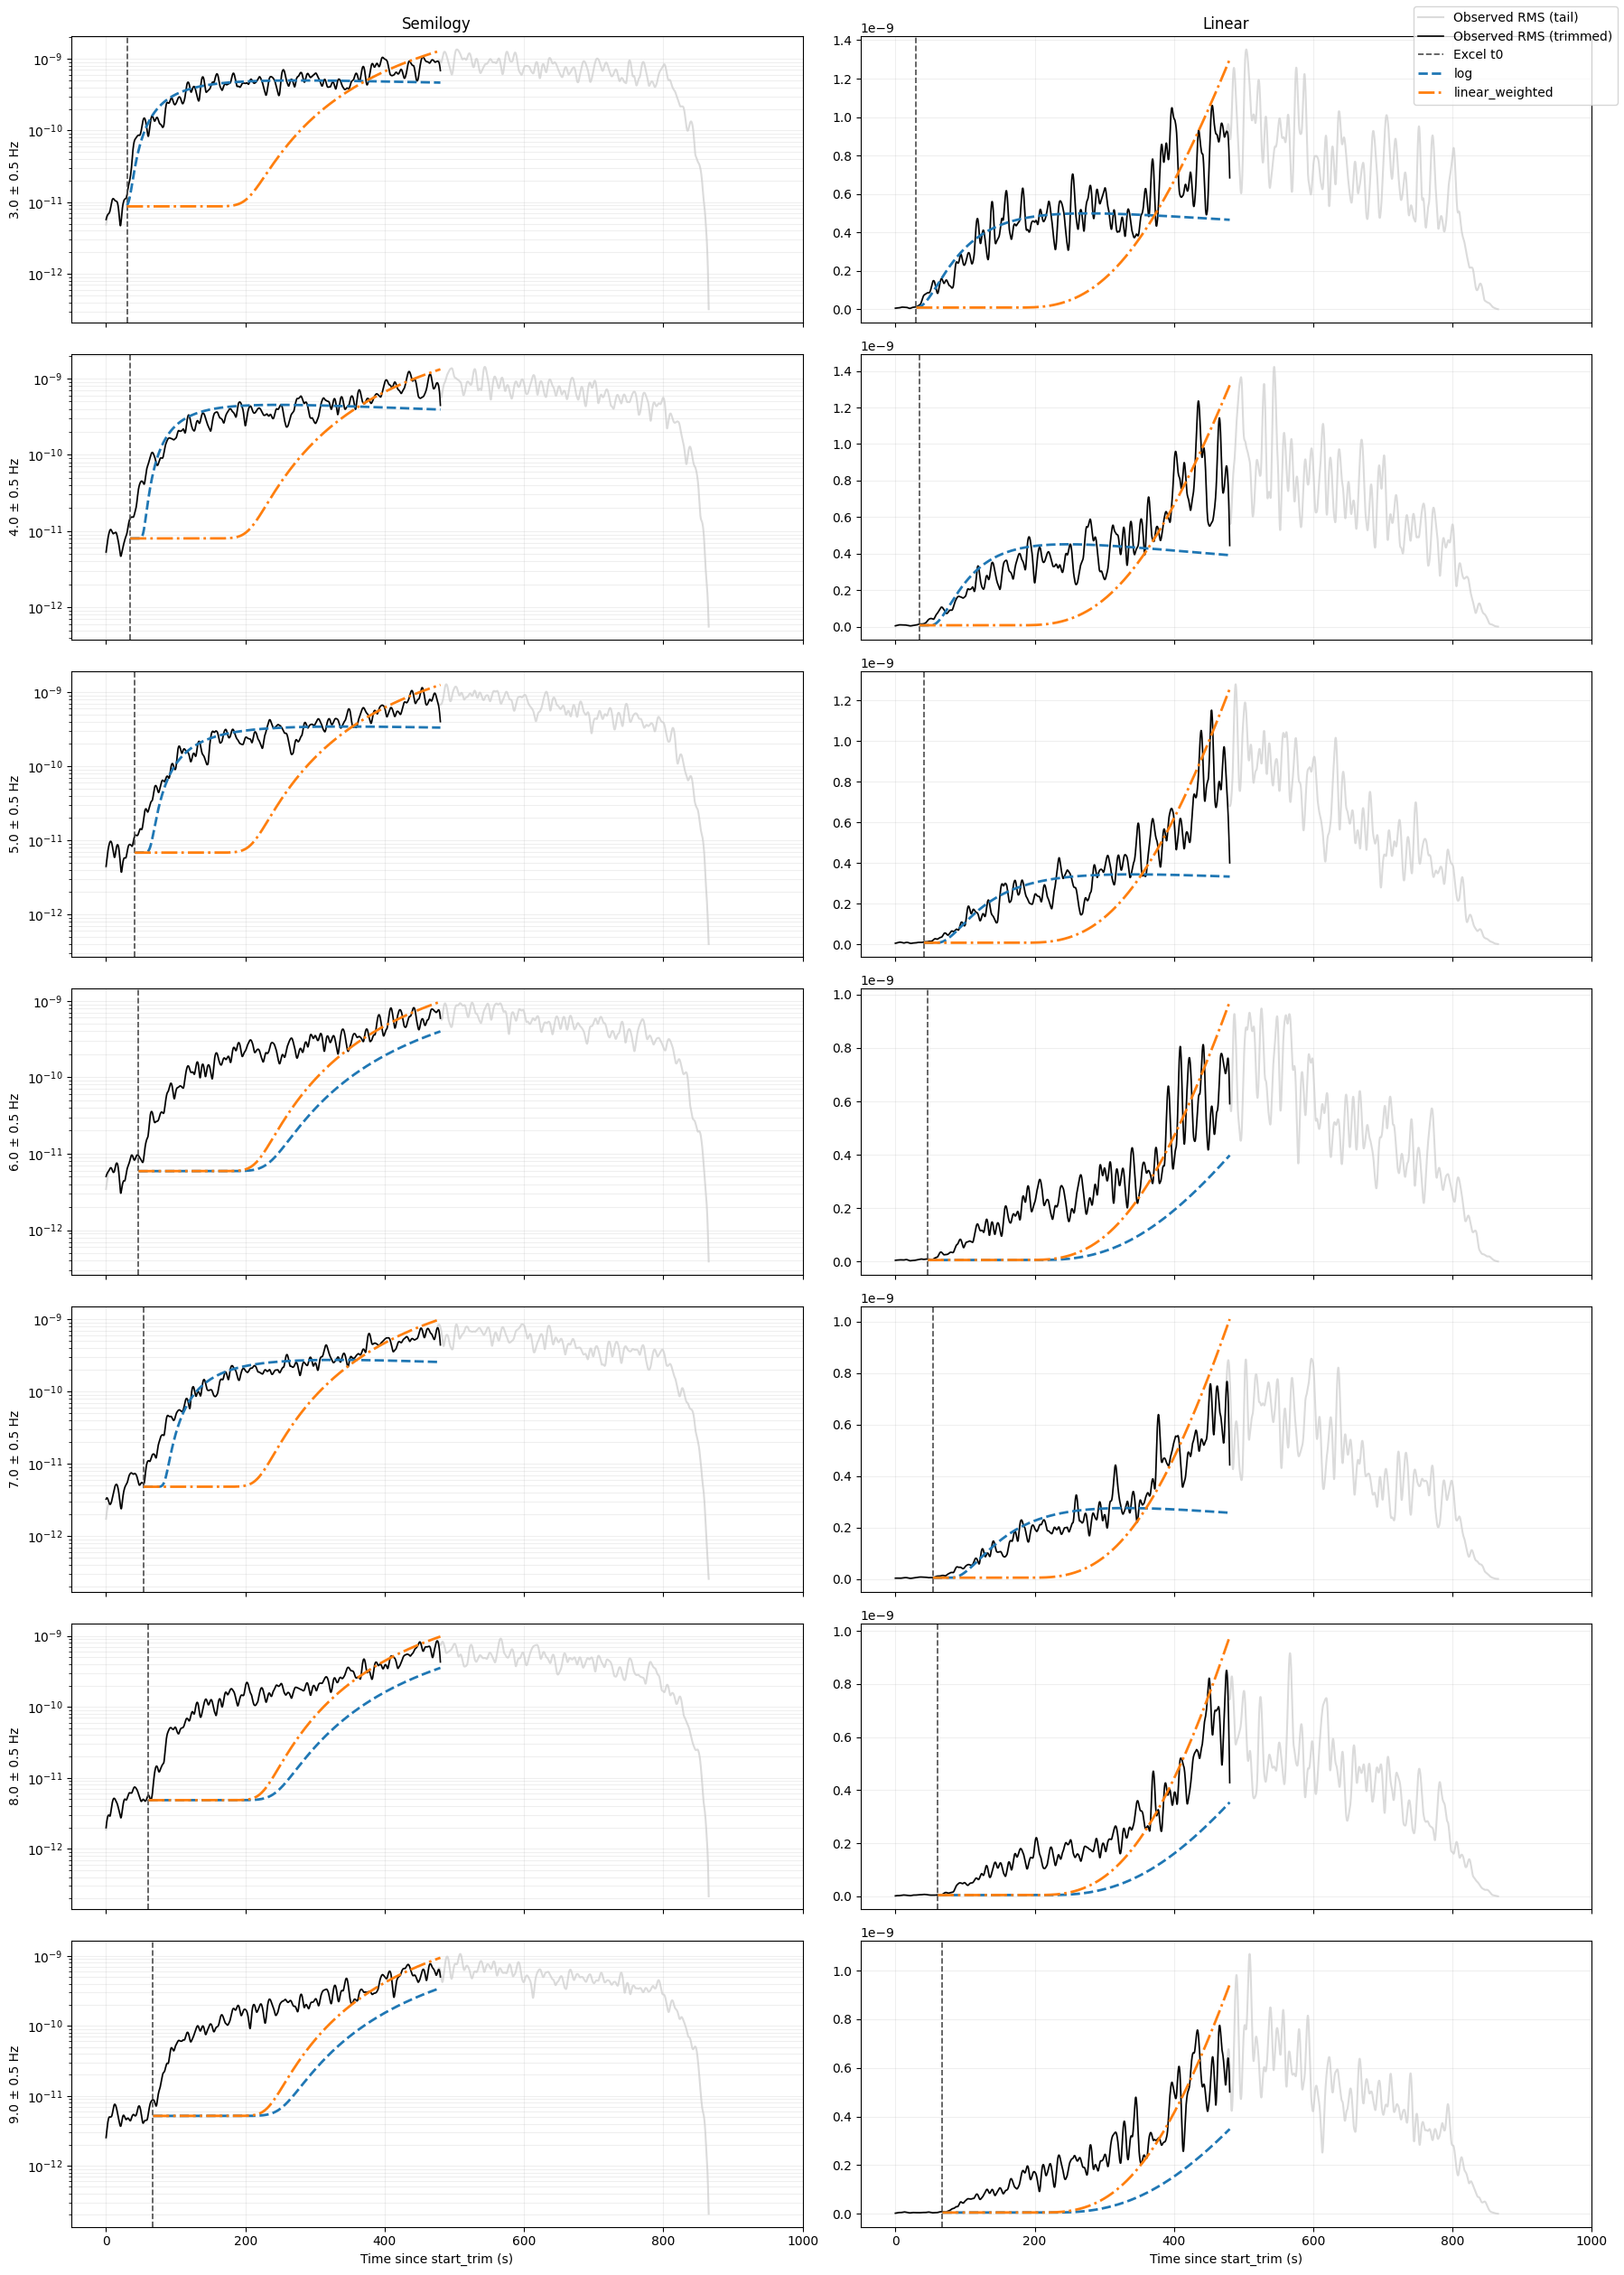

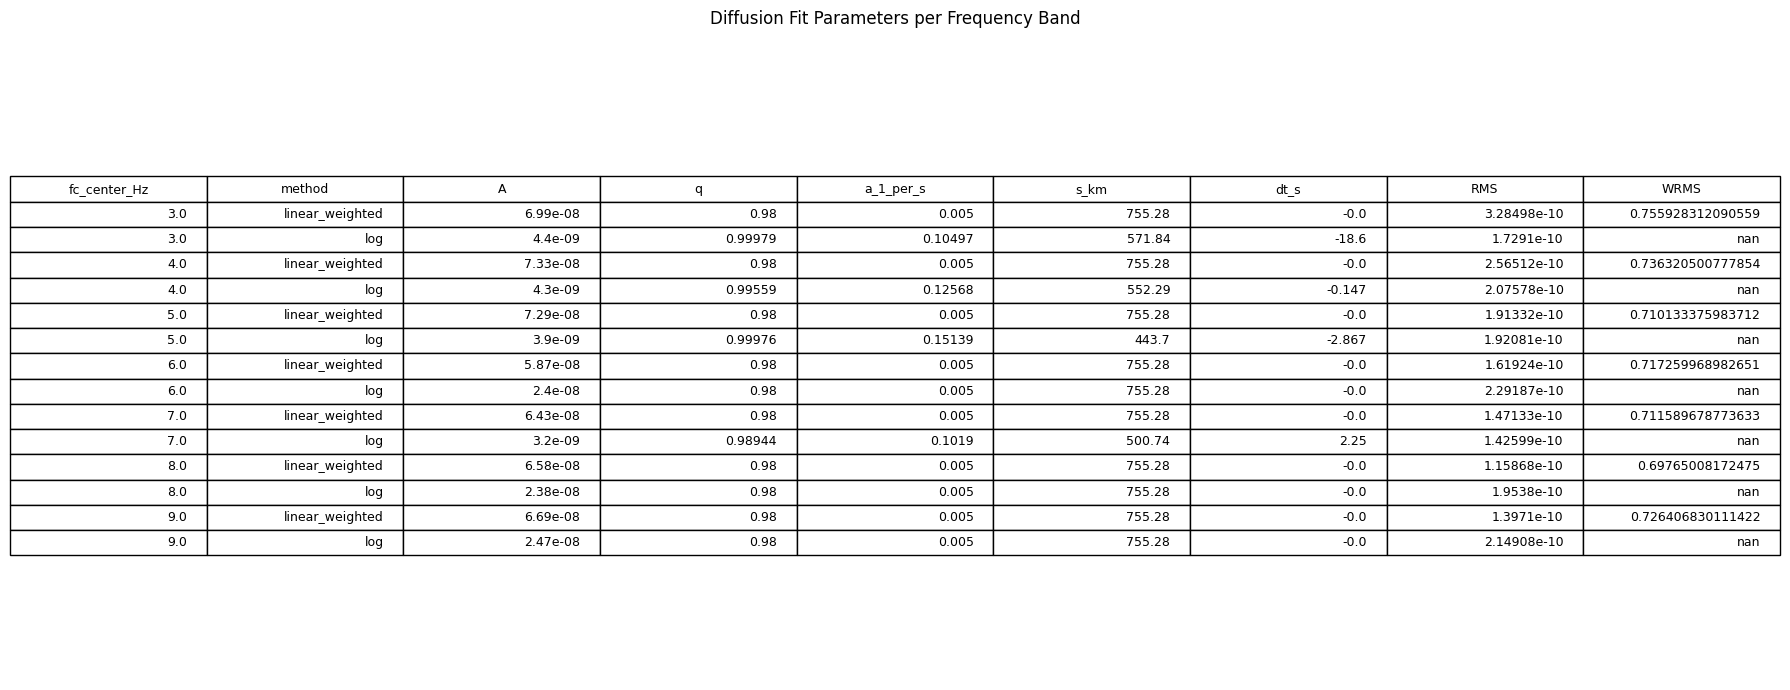

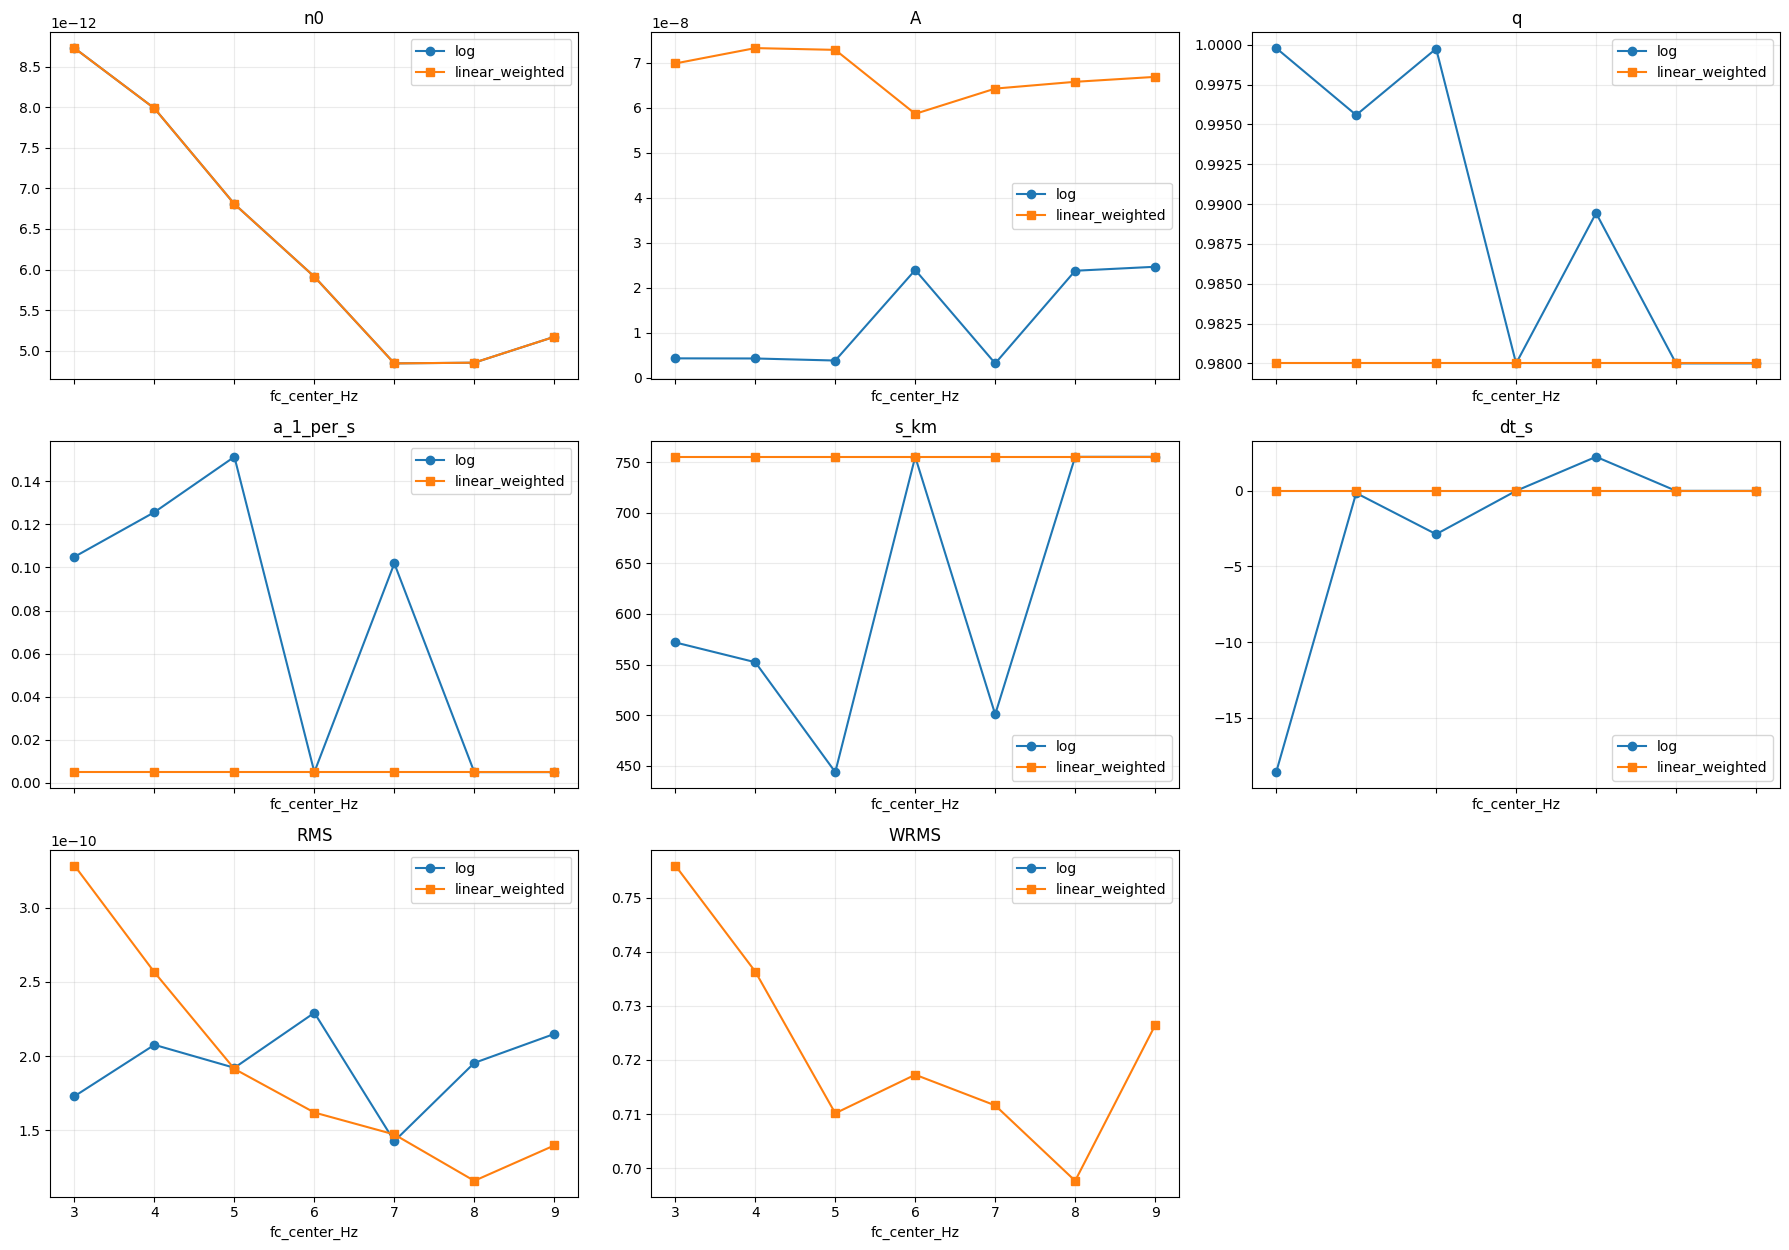

In [182]:


# ============================================================
# 2) Diffusion envelope: stable linear + stable log amplitude
# ============================================================
def _diffusion_log_e(tt, A, q, a, s, D):
    """
    log(amp_diff^2) without noise floor:
      amp_diff^2 = A^2 * q^(a t) / (a t) * exp( -D^2 / (s^2 a t) )
    """
    tt = np.asarray(tt, float)
    tt = np.maximum(tt, 1e-3)

    q = np.clip(q, 1e-12, 1 - 1e-12)
    a = np.maximum(a, 1e-12)
    s = np.maximum(s, 1e-6)
    A = np.maximum(A, 1e-30)

    return (
        2.0 * np.log(A)
        + (a * tt) * np.log(q)
        - np.log(a * tt)
        - (D**2) / (s**2 * a * tt)
    )

def diffusion_amp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """amp_total = sqrt( amp_diff(tt-dt)^2 + n0^2 )"""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)
    return np.sqrt(np.exp(log_e) + n0**2)

def diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """log(amp_total) stably via logaddexp."""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)      # log(amp_diff^2)
    log_n0sq = 2.0 * np.log(n0)                     # log(n0^2)

    return 0.5 * np.logaddexp(log_e, log_n0sq)




# ============================================================
# 3) Shared helpers: masks, init/bounds, misfits
# ============================================================
def _prepare_fit_data(t, amp, t0_mean, tmin_after_t0, t_end_safe=10.0):
    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    pre = t < (t0_mean - 10)
    if not np.any(pre):
        raise RuntimeError("No samples before t0_mean for noise floor estimate.")
    n0 = float(np.mean(amp[pre]))
    n0 = max(n0, 1e-30)

    t_eff = t - t0_mean

    # EXCLUDE last t_end_safe seconds (relative to end of trimmed window)
    t_end = t.max()
    mask = (t_eff > tmin_after_t0) & (t <= (t_end - t_end_safe)) & np.isfinite(amp) & (amp > 0)

    t_fit = t_eff[mask]
    amp_fit = amp[mask]

    if t_fit.size < 20:
        raise RuntimeError("Not enough valid samples after t0_mean for diffusion fit.")
    return n0, t_eff, t_fit, amp_fit


def _p0_bounds(amp_fit, D, fit_dt=True): # A, q, a, s, 
    if fit_dt:
        p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2), 0.0)
        bounds = (
            (1e-30, 1e-12, 1e-12, 1e-3,  -500),
            (1e+03, 1,    10,    1e6,   +500),
        )
    else:
        p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2))
        bounds = (
            (1e-30, 1e-12, 1e-12, 1e-3),
            (1e+03, 1,    10,    1e6),
        )
    return p0, bounds

def _misfits(amp_obs, amp_pred, sigma=None):
    amp_obs = np.asarray(amp_obs, float)
    amp_pred = np.asarray(amp_pred, float)
    resid = amp_obs - amp_pred

    out = {}
    out["RMS"] = float(np.sqrt(np.mean(resid**2)))
    out["Relative_RMS"] = float(np.sqrt(np.mean((resid / amp_obs) ** 2)))
    out["Log_RMS"] = float(np.sqrt(np.mean((np.log(amp_obs) - np.log(amp_pred)) ** 2)))

    if sigma is not None:
        sigma = np.asarray(sigma, float)
        out["WRMS"] = float(np.sqrt(np.mean((resid / sigma) ** 2)))
    return out


# ============================================================
# 4) Fit: (1) log-fit, (2) linear weighted
# ============================================================
def fit_three_ways(
    t, amp, *, D, t0_mean, tmin_after_t0=0.0, t_end_safe=10.0, fit_dt=False,
    weight_mode="hybrid",
    maxfev=500000 
):
    """
    Returns dict with keys: 'log', 'linear_weighted'
    Each entry has: popt, pcov, n0, t_fit, amp_fit, amp_pred_fit, misfit (+sigma for weighted)
    """
    n0, t_eff, t_fit, amp_fit = _prepare_fit_data(t, amp, t0_mean, tmin_after_t0)
    p0, bounds = _p0_bounds(amp_fit, D, fit_dt=fit_dt)

    # ---------- (1) LOG FIT ----------
    y_log = np.log(amp_fit)

    if fit_dt:
        def f_log(tt, A, q, a, s, dt):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt)
        popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
        A, q, a, s, dt = popt_log
    else:
        def f_log(tt, A, q, a, s):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0, 0.0)
        popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
        A, q, a, s = popt_log
        dt = 0.0

    amp_pred_log = diffusion_amp_floor(t_fit, A, q, a, s, D, n0, dt)
    mis_log = _misfits(amp_fit, amp_pred_log)

    # ---------- (2) LINEAR WEIGHTED ----------
    if weight_mode == "hybrid":
        sigma = np.sqrt(amp_fit**2 + n0**2)
    elif weight_mode == "relative":
        sigma = np.maximum(amp_fit, n0)
    elif weight_mode == "noise":
        sigma = np.full_like(amp_fit, n0, dtype=float)
    else:
        raise ValueError("weight_mode must be one of: 'hybrid', 'relative', 'noise'")

    if fit_dt:
        def f_lin(tt, A, q, a, s, dt):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0, dt)
        popt_w, pcov_w = curve_fit(
            f_lin, t_fit, amp_fit,
            p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False,
            maxfev=maxfev
        )
        A3, q3, a3, s3, dt3 = popt_w
    else:
        def f_lin(tt, A, q, a, s):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0, 0.0)
        popt_w, pcov_w = curve_fit(
            f_lin, t_fit, amp_fit,
            p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False,
            maxfev=maxfev
        )
        A3, q3, a3, s3 = popt_w
        dt3 = 0.0

    amp_pred_w = diffusion_amp_floor(t_fit, A3, q3, a3, s3, D, n0, dt3)
    mis_w = _misfits(amp_fit, amp_pred_w, sigma=sigma)

    return {
        "log": dict(
            popt=popt_log, pcov=pcov_log, n0=n0,
            t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_log,
            misfit=mis_log
        ),
        "linear_weighted": dict(
            popt=popt_w, pcov=pcov_w, n0=n0,
            t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_w,
            sigma=sigma, misfit=mis_w
        ),
    }


# ============================================================
# 5) Time trimming + setup (PER-BAND t0 references)
# ============================================================

# Per-band Excel t0s for the chosen event
t0_row = t0_mat.loc[chosen_event]  # Series indexed by band

# Choose a single trimming window that contains all band-specific t0's
# (use earliest available t0 across bands)
t0_min_utc = t0_row.dropna().min()
if pd.isna(t0_min_utc):
    raise RuntimeError(f"No t0_dt_mean available for any band for event={chosen_event}")

t0_min_obspy = UTCDateTime(t0_min_utc.to_pydatetime())

start_trim = t0_min_obspy - 30.0
end_trim   = t0_min_obspy + 450

# Short trimmed trace (for fitting)
tr_trimmed = tr_chosen.copy()
tr_trimmed.trim(starttime=start_trim, endtime=end_trim)

# Long tail trace (for plotting tail)
tr_tail = tr_chosen.copy()
tr_tail.trim(starttime=start_trim)

# Time axis for trimmed window (0 at start_trim)
t = tr_trimmed.times()
t_tail = tr_tail.times()

# Choose smoothing/bands
half_bw = 0.5
win_s   = 10
order   = 4

# IMPORTANT: use the same bands as your Excel bands (or a subset)
frequency_bands = BANDS.copy()

fs_trim = tr_trimmed.stats.sampling_rate
fs_tail = tr_tail.stats.sampling_rate

# Epicentral distance in km (your rule)
D_km = float(chosen_row["epi_deg"]) * 30.0

print("Global start_trim:", tr_trimmed.stats.starttime)
print("Earliest t0 (UTC):", t0_min_utc)
print("D_km:", D_km)
print("Number of bands:", len(frequency_bands))



# ============================================================
# 6) Loop bands: compute RMS, fit, store table rows, and plot 2×N figure
# ============================================================
methods = ["log", "linear_weighted"]
linestyles = {"log": "--", "linear_weighted": "-."}

n_bands = len(frequency_bands)
fig, axes = plt.subplots(
    nrows=n_bands,
    ncols=2,
    figsize=(18, 3.6 * n_bands),
    sharex=True
)

if n_bands == 1:
    axes = np.array([axes])

rows = []

for i, fc_band in enumerate(frequency_bands):
    # --- band-specific Excel t0 ---
    t0_utc_band = t0_row.get(fc_band, pd.NaT)
    if pd.isna(t0_utc_band):
        print(f"Skipping band {fc_band}: no t0 in Excel for event {chosen_event}")
        continue

    t0_obspy_band = UTCDateTime(t0_utc_band.to_pydatetime())
    t0_line_band = float(t0_obspy_band - tr_trimmed.stats.starttime)  # seconds since start_trim

    # --- trimmed RMS ---
    fl, fu = band_edges(fc_band, half_bw, fs_trim)
    env_trim, rms = env_and_rms(tr_trimmed.data.astype(float), fs_trim, fl, fu, win_s, order)

    # --- tail RMS ---
    fl_t, fu_t = band_edges(fc_band, half_bw, fs_tail)
    env_tail, rms_tail = env_and_rms(tr_tail.data.astype(float), fs_tail, fl_t, fu_t, win_s, order)

    # --- fit ---
    res = fit_three_ways(
        t, rms,
        D=D_km,
        t0_mean=t0_line_band,
        tmin_after_t0= -win_s/2,
        fit_dt=True,
        weight_mode="hybrid",
        t_end_safe=10.0
    )

    # --- model axis only after t0 ---
    t_eff_all = t - t0_line_band
    mask_model = t_eff_all > 0
    t_model = t_eff_all[mask_model]
    t_model_abs = t_model + t0_line_band

    # --- axes for this row ---
    ax_log = axes[i, 0]
    ax_lin = axes[i, 1]

    # Observations (label only once for shared legend)
    ax_log.semilogy(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
    ax_log.semilogy(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

    ax_lin.plot(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
    ax_lin.plot(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

    # t0 line
    ax_log.axvline(t0_line_band, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)
    ax_lin.axvline(t0_line_band, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)

    # Overlay both fitted models + store table rows
    for method in methods:
        popt = np.asarray(res[method]["popt"], float)
        n0 = float(res[method]["n0"])
        mis = res[method]["misfit"]

        if popt.size == 5:
            A, q, a, s, dt = popt
        else:
            A, q, a, s = popt
            dt = 0.0

        amp_model = diffusion_amp_floor(t_model, A, q, a, s, D_km, n0, dt)

        ax_log.semilogy(
            t_model_abs, amp_model,
            ls=linestyles[method], lw=2.0,
            label=method if i == 0 else None
        )
        ax_lin.plot(
            t_model_abs, amp_model,
            ls=linestyles[method], lw=2.0,
            label=method if i == 0 else None
        )



        rows.append({
            "fc_center_Hz": float(fc_band),
            "f_low_Hz": float(fc_band - half_bw),
            "f_high_Hz": float(fc_band + half_bw),
            "half_bw_Hz": float(half_bw),
            "win_s": float(win_s),
            "order": int(order),
            "D_km": float(D_km),
            "t0_line_s": float(t0_line_band),
            "t0_utc": pd.Timestamp(t0_utc_band),  # optional but very useful
            "method": method,
            "n0": n0,
            "A": float(A),
            "q": float(q),
            "a_1_per_s": float(a),
            "s_km": float(s),
            "dt_s": float(dt),
            "RMS": float(mis["RMS"]),
            "Relative_RMS": float(mis["Relative_RMS"]),
            "Log_RMS": float(mis["Log_RMS"]),
            "WRMS": float(mis.get("WRMS", np.nan)),
        })

    # Row formatting
    for ax in (ax_log, ax_lin):
        ax.set_xlim(-50, 1000)
        ax.grid(True, which="both", alpha=0.2)

    ax_log.set_ylabel(f"{fc_band:.1f} ± {half_bw:.1f} Hz")

    if i == 0:
        ax_log.set_title("Semilogy")
        ax_lin.set_title("Linear")

    if i == n_bands - 1:
        ax_log.set_xlabel("Time since start_trim (s)")
        ax_lin.set_xlabel("Time since start_trim (s)")

# Global legend (from first row)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# ============================================================
# 7) Create a formatted table in the figure (no printing)
# ============================================================

df_bands = (
    pd.DataFrame(rows)
    .sort_values(["fc_center_Hz", "method"])
    .reset_index(drop=True)
)

# Round values for readability
df_display = df_bands.copy()
df_display = df_display.round({
    "A": 10,
    "q": 5,
    "a_1_per_s": 5,
    "s_km": 2,
    "dt_s": 3,
    "RMS": 15,
    "Relative_RMS": 15,
    "Log_RMS": 15,
    "WRMS": 15,
})

# Select only the columns you want to show
cols_to_show = [
    "fc_center_Hz",
    "method",
    "A",
    "q",
    "a_1_per_s",
    "s_km",
    "dt_s",
    "RMS",
    "WRMS"
]

df_display = df_display[cols_to_show]

# ---- Create table figure ----
fig_table, ax_table = plt.subplots(figsize=(18, 0.5 * len(df_display)))
ax_table.axis("off")

table = ax_table.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.3)

plt.title("Diffusion Fit Parameters per Frequency Band", pad=20)
plt.tight_layout()
plt.show()
# ============================================================
# 8) Parameter-vs-frequency summary figure (subplots)
# ============================================================

# Ensure df exists
df_bands = (
    pd.DataFrame(rows)
    .sort_values(["fc_center_Hz", "method"])
    .reset_index(drop=True)
)

# Parameters to plot
params = ["n0", "A", "q", "a_1_per_s", "s_km", "dt_s", "RMS", "WRMS"]

# Pivot: index = frequency, columns = method, values = parameter
wide = {}
for p in params:
    wide[p] = df_bands.pivot(index="fc_center_Hz", columns="method", values=p)

# Subplot layout
n = len(params)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.2 * nrows), sharex=True)
axes = np.atleast_2d(axes).ravel()

for ax, p in zip(axes, params):
    w = wide[p]

    # x = frequencies
    x = w.index.values

    # plot both methods if present
    if "log" in w.columns:
        ax.plot(x, w["log"].values, marker="o", label="log")
    if "linear_weighted" in w.columns:
        ax.plot(x, w["linear_weighted"].values, marker="s", label="linear_weighted")

    ax.set_title(p)
    ax.set_xlabel("fc_center_Hz")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True)

# Hide unused axes
for ax in axes[len(params):]:
    ax.axis("off")

plt.tight_layout()

plt.show()



Global start_trim: 1974-07-11T00:51:34.723226Z
Earliest t0 (UTC): 1974-07-11 00:52:04.720000+00:00
D_km: 3021.137307170133
Number of bands: 7


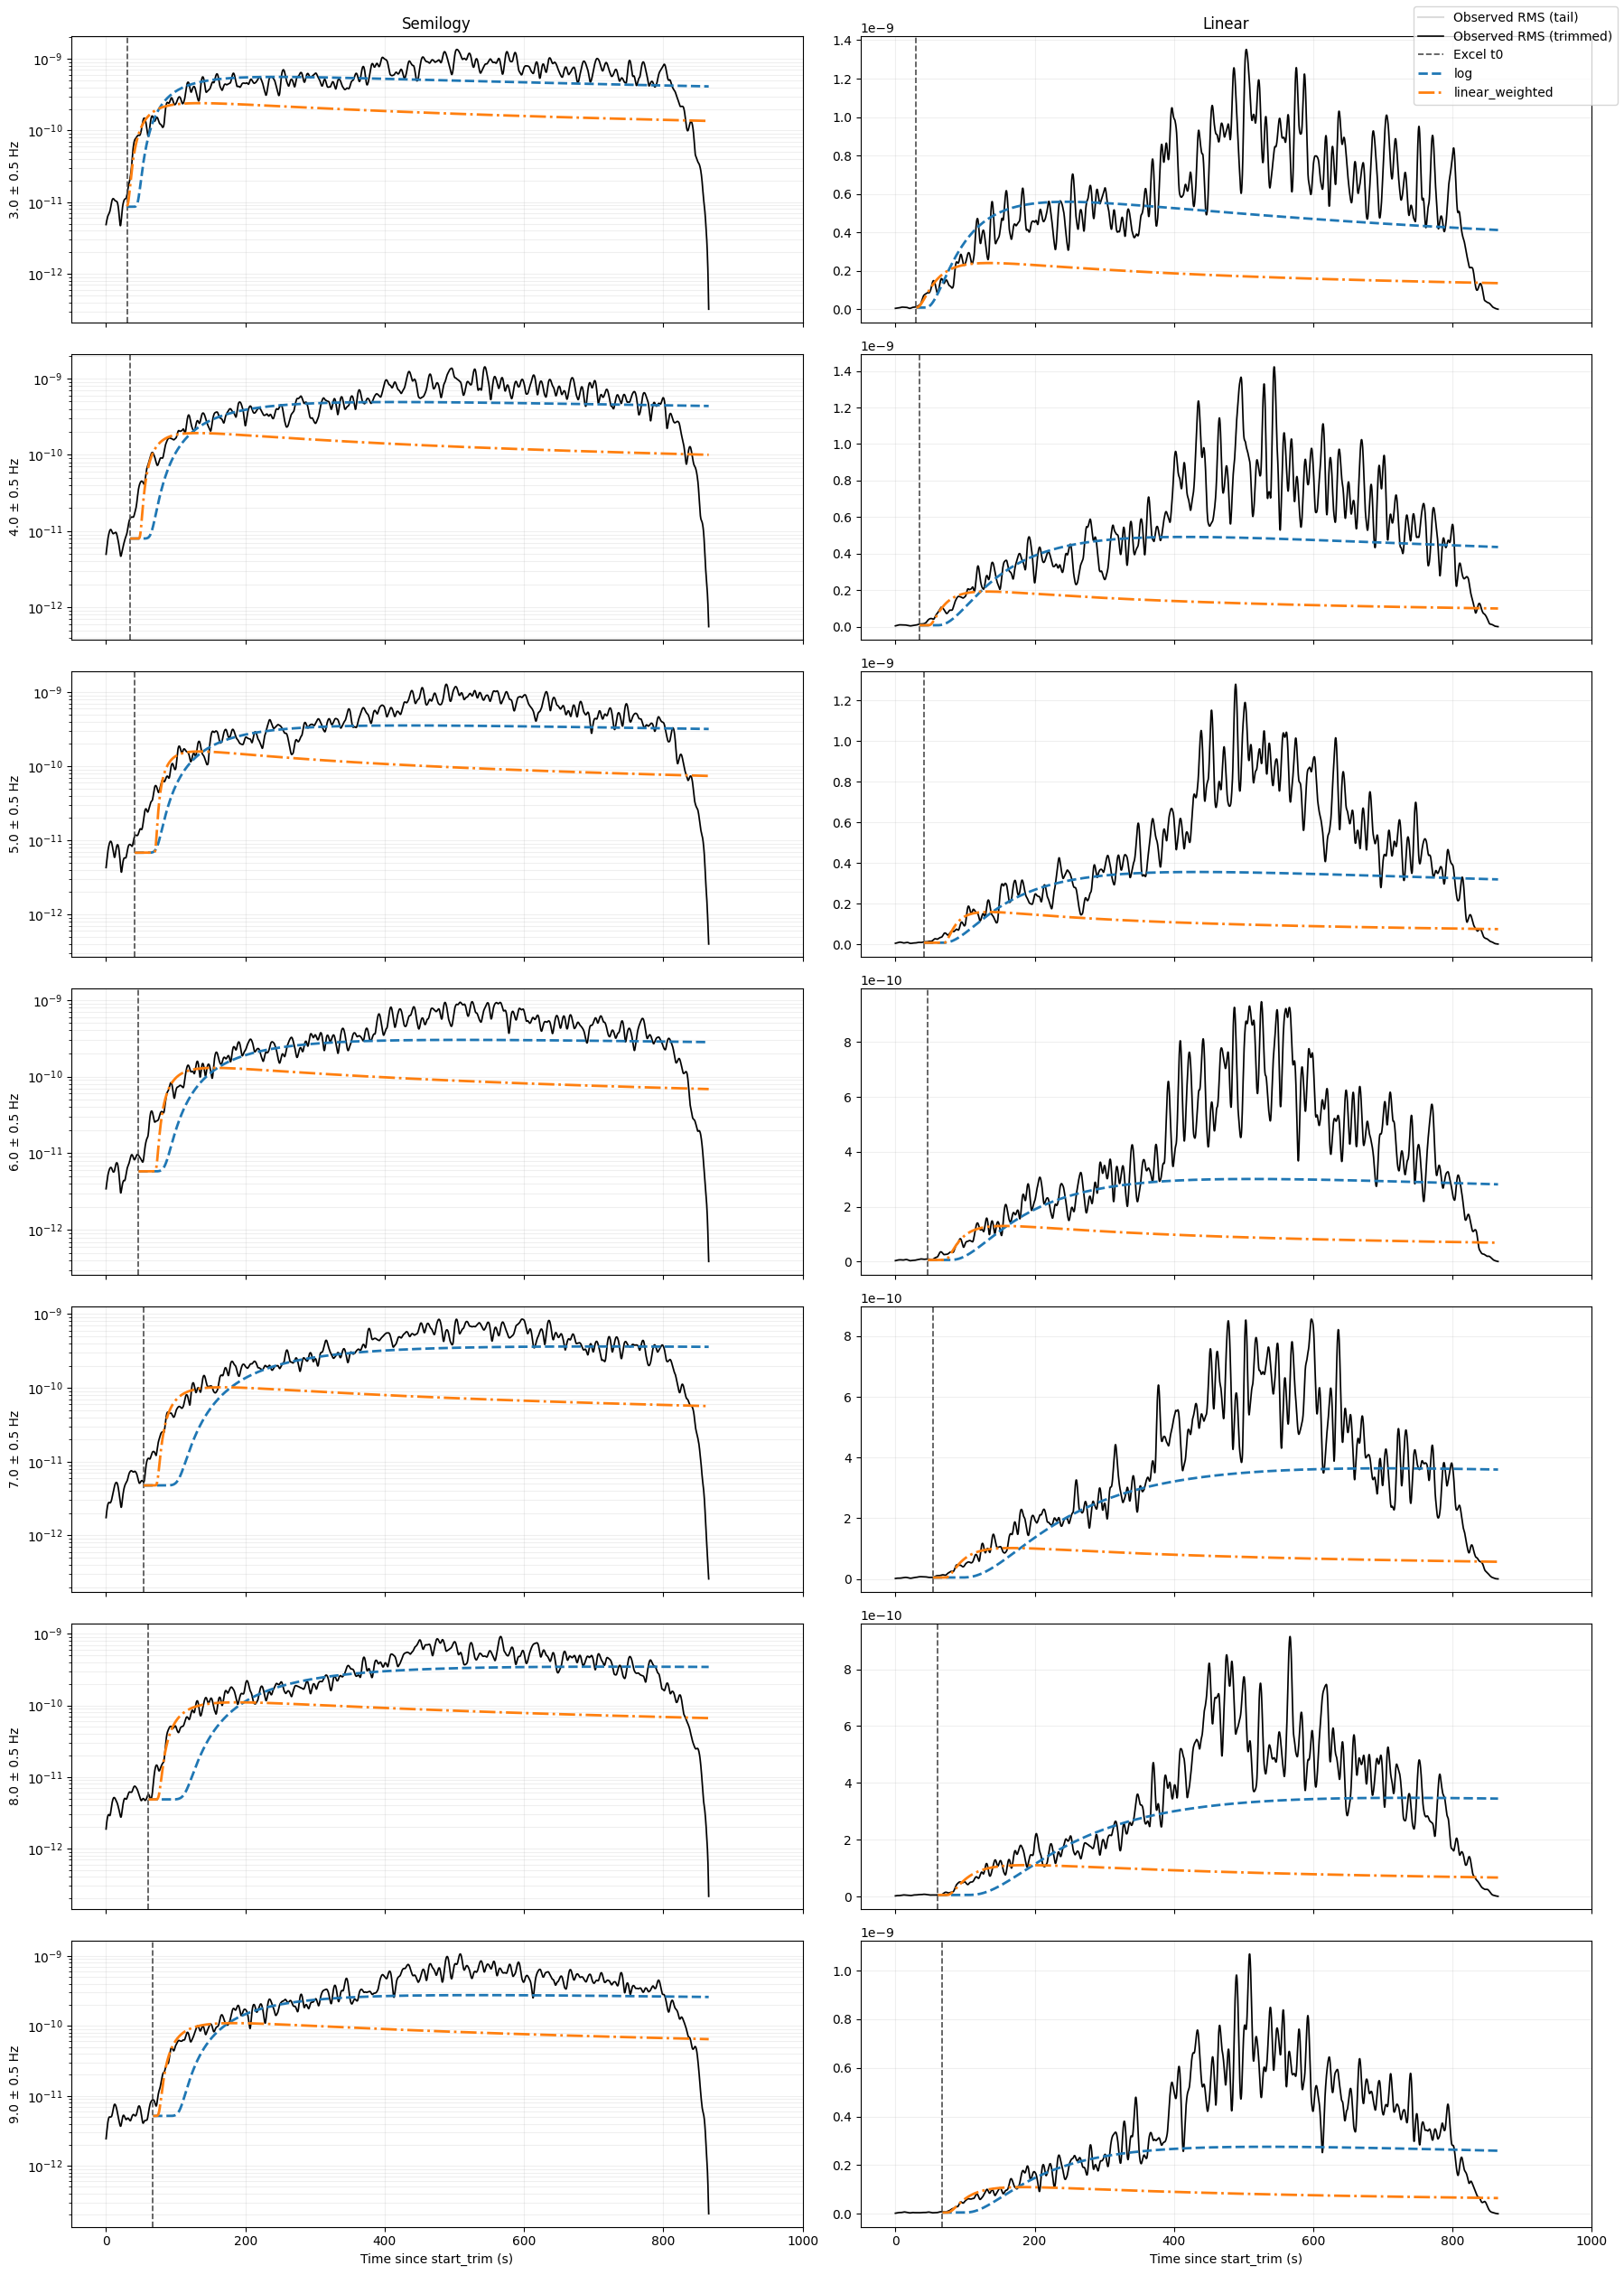

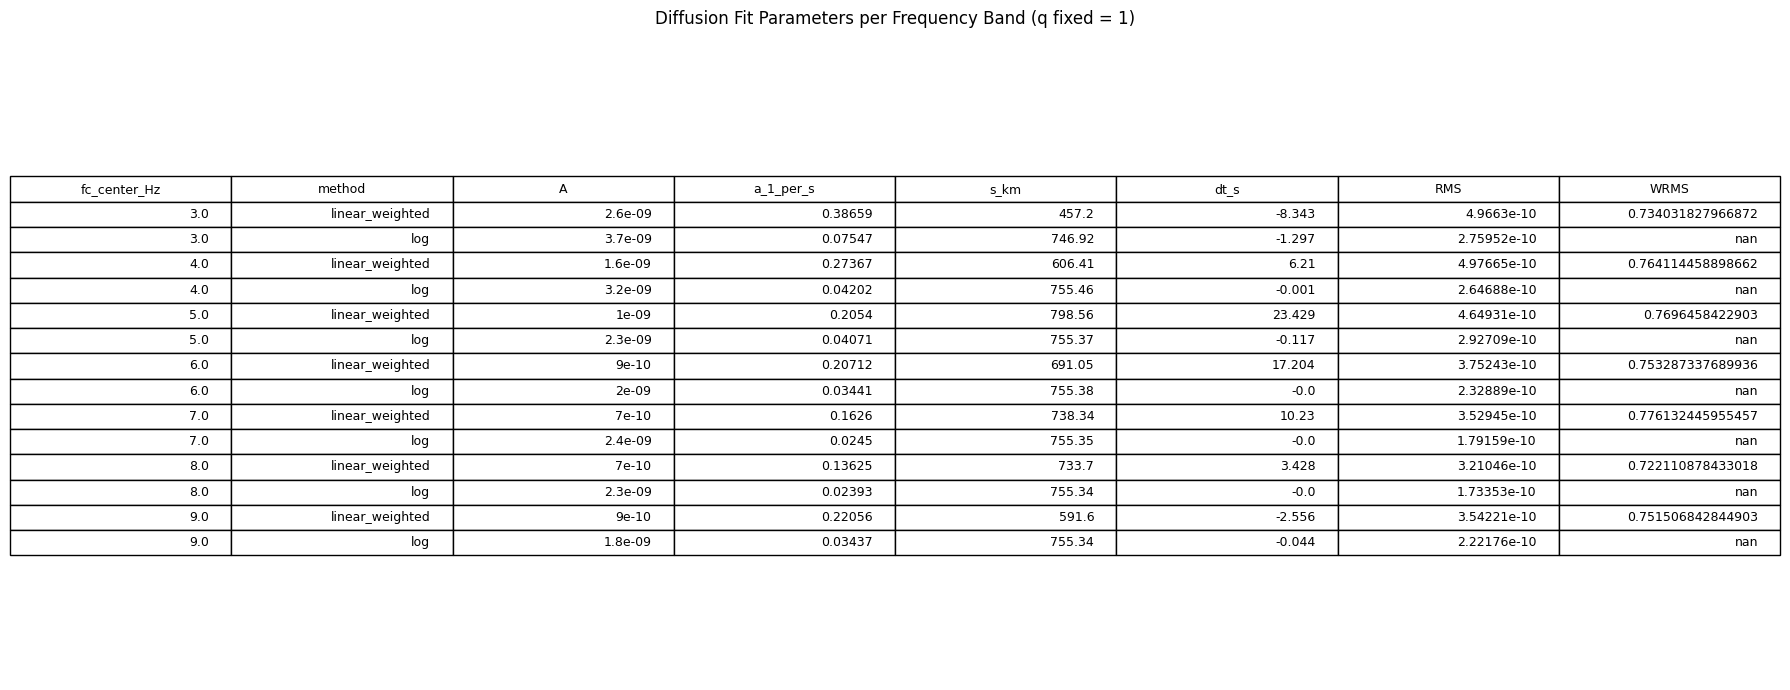

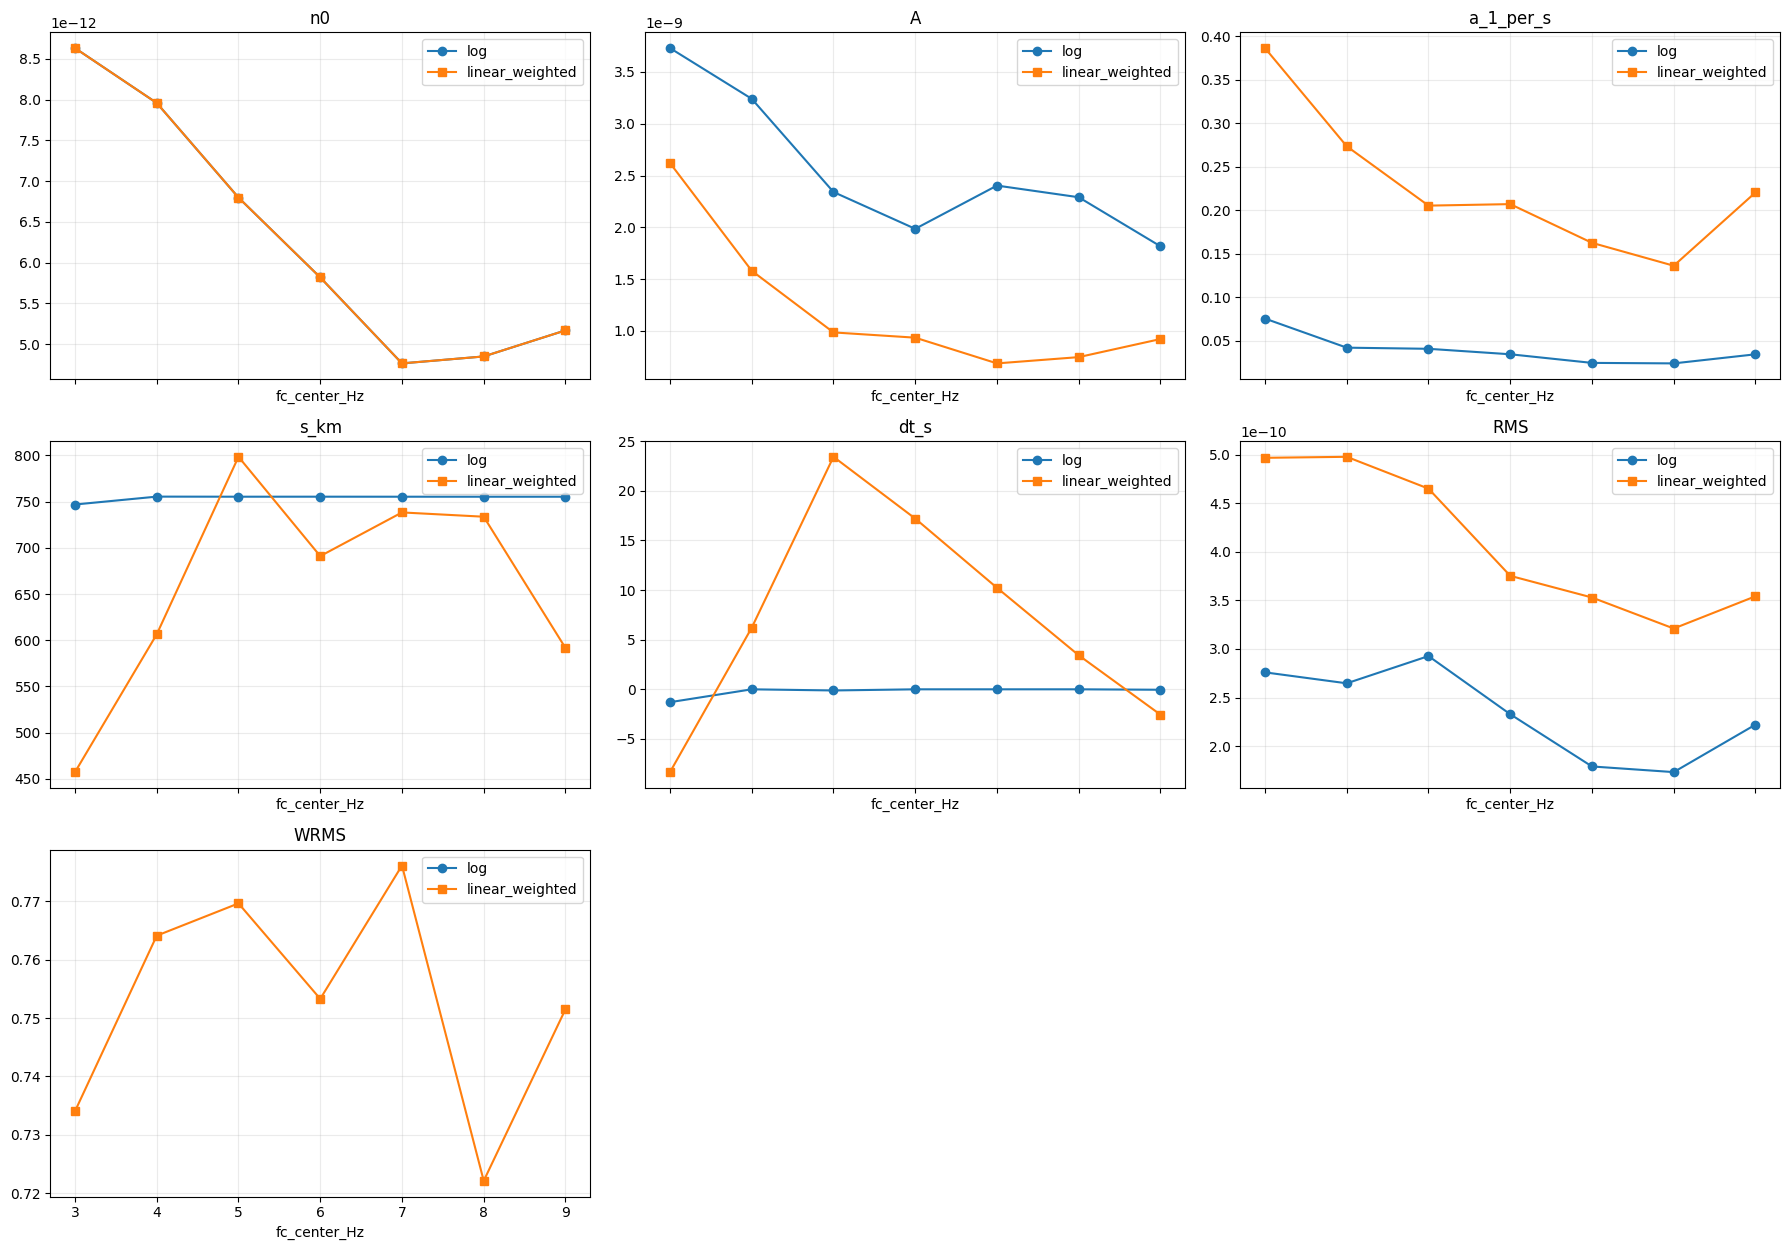

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit
# from obspy import UTCDateTime

# # ============================================================
# # 2) Diffusion envelope: stable linear + stable log amplitude
# #    FIX: q is NOT a free parameter anymore (q ≡ 1)
# # ============================================================
# def _diffusion_log_e_q1(tt, A, a, s, D):
#     """
#     log(amp_diff^2) without noise floor, with q fixed to 1:
#       amp_diff^2 = A^2 / (a t) * exp( -D^2 / (s^2 a t) )

#     (Since q^(a t) = 1 for q=1.)
#     """
#     tt = np.asarray(tt, float)
#     tt = np.maximum(tt, 1e-3)

#     a = np.maximum(a, 1e-12)
#     s = np.maximum(s, 1e-6)
#     A = np.maximum(A, 1e-30)

#     return (
#         2.0 * np.log(A)
#         - np.log(a * tt)
#         - (D**2) / (s**2 * a * tt)
#     )

# def diffusion_amp_floor_q1(tt, A, a, s, D, n0, dt=0.0):
#     """amp_total = sqrt( amp_diff(tt-dt)^2 + n0^2 ), with q fixed to 1."""
#     tt = np.asarray(tt, float)
#     x = np.maximum(tt - dt, 1e-3)

#     n0 = np.maximum(float(n0), 1e-30)
#     log_e = _diffusion_log_e_q1(x, A, a, s, D)
#     return np.sqrt(np.exp(log_e) + n0**2)

# def diffusion_logamp_floor_q1(tt, A, a, s, D, n0, dt=0.0):
#     """log(amp_total) stably via logaddexp, with q fixed to 1."""
#     tt = np.asarray(tt, float)
#     x = np.maximum(tt - dt, 1e-3)

#     n0 = np.maximum(float(n0), 1e-30)
#     log_e = _diffusion_log_e_q1(x, A, a, s, D)  # log(amp_diff^2)
#     log_n0sq = 2.0 * np.log(n0)                 # log(n0^2)

#     return 0.5 * np.logaddexp(log_e, log_n0sq)


# # ============================================================
# # 3) Shared helpers: masks, init/bounds, misfits
# # ============================================================
# def _prepare_fit_data(t, amp, t0_mean, tmin_after_t0, t_end_safe=10.0):
#     t = np.asarray(t, float)
#     amp = np.asarray(amp, float)

#     pre = t < (t0_mean - 10)
#     if not np.any(pre):
#         raise RuntimeError("No samples before t0_mean for noise floor estimate.")
#     n0 = float(np.mean(amp[pre]))
#     n0 = max(n0, 1e-30)

#     t_eff = t - t0_mean

#     # EXCLUDE last t_end_safe seconds (relative to end of trimmed window)
#     t_end = t.max()
#     mask = (t_eff > tmin_after_t0) & (t <= (t_end - t_end_safe)) & np.isfinite(amp) & (amp > 0)

#     t_fit = t_eff[mask]
#     amp_fit = amp[mask]

#     if t_fit.size < 20:
#         raise RuntimeError("Not enough valid samples after t0_mean for diffusion fit.")
#     return n0, t_eff, t_fit, amp_fit


# def _p0_bounds_q1(amp_fit, D, fit_dt=True):  # A, a, s, (dt)
#     if fit_dt:
#         p0 = (np.median(amp_fit), 5e-3, max(D / 4, 1e-2), 0.0)
#         bounds = (
#             (1e-30, 1e-12, 1e-3,  -500),
#             (1e+03, 10.0,  1e6,   +500),
#         )
#     else:
#         p0 = (np.median(amp_fit), 5e-3, max(D / 4, 1e-2))
#         bounds = (
#             (1e-30, 1e-12, 1e-3),
#             (1e+03, 10.0,  1e6),
#         )
#     return p0, bounds

# def _misfits(amp_obs, amp_pred, sigma=None):
#     amp_obs = np.asarray(amp_obs, float)
#     amp_pred = np.asarray(amp_pred, float)
#     resid = amp_obs - amp_pred

#     out = {}
#     out["RMS"] = float(np.sqrt(np.mean(resid**2)))
#     out["Relative_RMS"] = float(np.sqrt(np.mean((resid / amp_obs) ** 2)))
#     out["Log_RMS"] = float(np.sqrt(np.mean((np.log(amp_obs) - np.log(amp_pred)) ** 2)))

#     if sigma is not None:
#         sigma = np.asarray(sigma, float)
#         out["WRMS"] = float(np.sqrt(np.mean((resid / sigma) ** 2)))
#     return out


# # ============================================================
# # 4) Fit: (1) log-fit, (2) linear weighted
# #    FIX: q removed from fit entirely
# # ============================================================
# def fit_three_ways_q1(
#     t, amp, *, D, t0_mean, tmin_after_t0=0.0, t_end_safe=10.0, fit_dt=False,
#     weight_mode="hybrid",
#     maxfev=500000
# ):
#     """
#     Returns dict with keys: 'log', 'linear_weighted'
#     Each entry has: popt, pcov, n0, t_fit, amp_fit, amp_pred_fit, misfit (+sigma for weighted)

#     popt ordering:
#       - if fit_dt: (A, a, s, dt)
#       - else:     (A, a, s)
#     """
#     n0, t_eff, t_fit, amp_fit = _prepare_fit_data(t, amp, t0_mean, tmin_after_t0)
#     p0, bounds = _p0_bounds_q1(amp_fit, D, fit_dt=fit_dt)

#     # ---------- (1) LOG FIT ----------
#     y_log = np.log(amp_fit)

#     if fit_dt:
#         def f_log(tt, A, a, s, dt):
#             return diffusion_logamp_floor_q1(tt, A, a, s, D, n0, dt)
#         popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
#         A, a, s, dt = popt_log
#     else:
#         def f_log(tt, A, a, s):
#             return diffusion_logamp_floor_q1(tt, A, a, s, D, n0, 0.0)
#         popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
#         A, a, s = popt_log
#         dt = 0.0

#     amp_pred_log = diffusion_amp_floor_q1(t_fit, A, a, s, D, n0, dt)
#     mis_log = _misfits(amp_fit, amp_pred_log)

#     # ---------- (2) LINEAR WEIGHTED ----------
#     if weight_mode == "hybrid":
#         sigma = np.sqrt(amp_fit**2 + n0**2)
#     elif weight_mode == "relative":
#         sigma = np.maximum(amp_fit, n0)
#     elif weight_mode == "noise":
#         sigma = np.full_like(amp_fit, n0, dtype=float)
#     else:
#         raise ValueError("weight_mode must be one of: 'hybrid', 'relative', 'noise'")

#     if fit_dt:
#         def f_lin(tt, A, a, s, dt):
#             return diffusion_amp_floor_q1(tt, A, a, s, D, n0, dt)
#         popt_w, pcov_w = curve_fit(
#             f_lin, t_fit, amp_fit,
#             p0=p0, bounds=bounds,
#             sigma=sigma, absolute_sigma=False,
#             maxfev=maxfev
#         )
#         A3, a3, s3, dt3 = popt_w
#     else:
#         def f_lin(tt, A, a, s):
#             return diffusion_amp_floor_q1(tt, A, a, s, D, n0, 0.0)
#         popt_w, pcov_w = curve_fit(
#             f_lin, t_fit, amp_fit,
#             p0=p0, bounds=bounds,
#             sigma=sigma, absolute_sigma=False,
#             maxfev=maxfev
#         )
#         A3, a3, s3 = popt_w
#         dt3 = 0.0

#     amp_pred_w = diffusion_amp_floor_q1(t_fit, A3, a3, s3, D, n0, dt3)
#     mis_w = _misfits(amp_fit, amp_pred_w, sigma=sigma)

#     return {
#         "log": dict(
#             popt=popt_log, pcov=pcov_log, n0=n0,
#             t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_log,
#             misfit=mis_log
#         ),
#         "linear_weighted": dict(
#             popt=popt_w, pcov=pcov_w, n0=n0,
#             t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_w,
#             sigma=sigma, misfit=mis_w
#         ),
#     }


# # ============================================================
# # 5) Time trimming + setup (PER-BAND t0 references)
# # ============================================================

# # Per-band Excel t0s for the chosen event
# t0_row = t0_mat.loc[chosen_event]  # Series indexed by band

# # Choose a single trimming window that contains all band-specific t0's
# # (use earliest available t0 across bands)
# t0_min_utc = t0_row.dropna().min()
# if pd.isna(t0_min_utc):
#     raise RuntimeError(f"No t0_dt_mean available for any band for event={chosen_event}")

# t0_min_obspy = UTCDateTime(t0_min_utc.to_pydatetime())

# start_trim = t0_min_obspy - 30.0
# end_trim   = t0_min_obspy + 4000

# # Short trimmed trace (for fitting)
# tr_trimmed = tr_chosen.copy()
# tr_trimmed.trim(starttime=start_trim, endtime=end_trim)

# # Long tail trace (for plotting tail)
# tr_tail = tr_chosen.copy()
# tr_tail.trim(starttime=start_trim)

# # Time axis for trimmed window (0 at start_trim)
# t = tr_trimmed.times()
# t_tail = tr_tail.times()

# # Choose smoothing/bands
# half_bw = 0.5
# win_s   = 10
# order   = 4

# # IMPORTANT: use the same bands as your Excel bands (or a subset)
# frequency_bands = BANDS.copy()

# fs_trim = tr_trimmed.stats.sampling_rate
# fs_tail = tr_tail.stats.sampling_rate

# # Epicentral distance in km (your rule)
# D_km = float(chosen_row["epi_deg"]) * 30.0

# print("Global start_trim:", tr_trimmed.stats.starttime)
# print("Earliest t0 (UTC):", t0_min_utc)
# print("D_km:", D_km)
# print("Number of bands:", len(frequency_bands))


# # ============================================================
# # 6) Loop bands: compute RMS, fit, store table rows, and plot 2×N figure
# # ============================================================
# methods = ["log", "linear_weighted"]
# linestyles = {"log": "--", "linear_weighted": "-."}

# n_bands = len(frequency_bands)
# fig, axes = plt.subplots(
#     nrows=n_bands,
#     ncols=2,
#     figsize=(18, 3.6 * n_bands),
#     sharex=True
# )

# if n_bands == 1:
#     axes = np.array([axes])

# rows = []

# for i, fc_band in enumerate(frequency_bands):
#     # --- band-specific Excel t0 ---
#     t0_utc_band = t0_row.get(fc_band, pd.NaT)
#     if pd.isna(t0_utc_band):
#         print(f"Skipping band {fc_band}: no t0 in Excel for event {chosen_event}")
#         continue

#     t0_obspy_band = UTCDateTime(t0_utc_band.to_pydatetime())
#     t0_line_band = float(t0_obspy_band - tr_trimmed.stats.starttime)  # seconds since start_trim

#     # --- trimmed RMS ---
#     fl, fu = band_edges(fc_band, half_bw, fs_trim)
#     env_trim, rms = env_and_rms(tr_trimmed.data.astype(float), fs_trim, fl, fu, win_s, order)

#     # --- tail RMS ---
#     fl_t, fu_t = band_edges(fc_band, half_bw, fs_tail)
#     env_tail, rms_tail = env_and_rms(tr_tail.data.astype(float), fs_tail, fl_t, fu_t, win_s, order)

#     # --- fit (q fixed) ---
#     res = fit_three_ways_q1(
#         t, rms,
#         D=D_km,
#         t0_mean=t0_line_band,
#         tmin_after_t0= -win_s/2,
#         fit_dt=True,
#         weight_mode="hybrid",
#         t_end_safe=10.0
#     )

#     # --- model axis only after t0 ---
#     t_eff_all = t - t0_line_band
#     mask_model = t_eff_all > 0
#     t_model = t_eff_all[mask_model]
#     t_model_abs = t_model + t0_line_band

#     # --- axes for this row ---
#     ax_log = axes[i, 0]
#     ax_lin = axes[i, 1]

#     # Observations (label only once for shared legend)
#     ax_log.semilogy(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
#     ax_log.semilogy(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

#     ax_lin.plot(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
#     ax_lin.plot(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

#     # t0 line
#     ax_log.axvline(t0_line_band, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)
#     ax_lin.axvline(t0_line_band, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)

#     # Overlay both fitted models + store table rows
#     for method in methods:
#         popt = np.asarray(res[method]["popt"], float)
#         n0 = float(res[method]["n0"])
#         mis = res[method]["misfit"]

#         if popt.size == 4:
#             A, a, s, dt = popt
#         else:
#             A, a, s = popt
#             dt = 0.0

#         amp_model = diffusion_amp_floor_q1(t_model, A, a, s, D_km, n0, dt)

#         ax_log.semilogy(
#             t_model_abs, amp_model,
#             ls=linestyles[method], lw=2.0,
#             label=method if i == 0 else None
#         )
#         ax_lin.plot(
#             t_model_abs, amp_model,
#             ls=linestyles[method], lw=2.0,
#             label=method if i == 0 else None
#         )

#         rows.append({
#             "fc_center_Hz": float(fc_band),
#             "f_low_Hz": float(fc_band - half_bw),
#             "f_high_Hz": float(fc_band + half_bw),
#             "half_bw_Hz": float(half_bw),
#             "win_s": float(win_s),
#             "order": int(order),
#             "D_km": float(D_km),
#             "t0_line_s": float(t0_line_band),
#             "t0_utc": pd.Timestamp(t0_utc_band),
#             "method": method,
#             "n0": n0,
#             "A": float(A),
#             "a_1_per_s": float(a),
#             "s_km": float(s),
#             "dt_s": float(dt),
#             "RMS": float(mis["RMS"]),
#             "Relative_RMS": float(mis["Relative_RMS"]),
#             "Log_RMS": float(mis["Log_RMS"]),
#             "WRMS": float(mis.get("WRMS", np.nan)),
#         })

#     # Row formatting
#     for ax in (ax_log, ax_lin):
#         ax.set_xlim(-50, 1000)
#         ax.grid(True, which="both", alpha=0.2)

#     ax_log.set_ylabel(f"{fc_band:.1f} ± {half_bw:.1f} Hz")

#     if i == 0:
#         ax_log.set_title("Semilogy")
#         ax_lin.set_title("Linear")

#     if i == n_bands - 1:
#         ax_log.set_xlabel("Time since start_trim (s)")
#         ax_lin.set_xlabel("Time since start_trim (s)")

# # Global legend (from first row)
# handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", frameon=True)

# plt.tight_layout()
# plt.show()


# # ============================================================
# # 7) Create a formatted table in the figure (no printing)
# # ============================================================
# df_bands = (
#     pd.DataFrame(rows)
#     .sort_values(["fc_center_Hz", "method"])
#     .reset_index(drop=True)
# )

# df_display = df_bands.copy()
# df_display = df_display.round({
#     "A": 10,
#     "a_1_per_s": 5,
#     "s_km": 2,
#     "dt_s": 3,
#     "RMS": 15,
#     "Relative_RMS": 15,
#     "Log_RMS": 15,
#     "WRMS": 15,
# })

# cols_to_show = [
#     "fc_center_Hz",
#     "method",
#     "A",
#     "a_1_per_s",
#     "s_km",
#     "dt_s",
#     "RMS",
#     "WRMS"
# ]
# df_display = df_display[cols_to_show]

# fig_table, ax_table = plt.subplots(figsize=(18, 0.5 * len(df_display)))
# ax_table.axis("off")

# table = ax_table.table(
#     cellText=df_display.values,
#     colLabels=df_display.columns,
#     loc="center"
# )

# table.auto_set_font_size(False)
# table.set_fontsize(9)
# table.scale(1.0, 1.3)

# plt.title("Diffusion Fit Parameters per Frequency Band (q fixed = 1)", pad=20)
# plt.tight_layout()
# plt.show()


# # ============================================================
# # 8) Parameter-vs-frequency summary figure (subplots)
# # ============================================================
# df_bands = (
#     pd.DataFrame(rows)
#     .sort_values(["fc_center_Hz", "method"])
#     .reset_index(drop=True)
# )

# params = ["n0", "A", "a_1_per_s", "s_km", "dt_s", "RMS", "WRMS"]

# wide = {}
# for p in params:
#     wide[p] = df_bands.pivot(index="fc_center_Hz", columns="method", values=p)

# n = len(params)
# ncols = 3
# nrows = int(np.ceil(n / ncols))
# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.2 * nrows), sharex=True)
# axes = np.atleast_2d(axes).ravel()

# for ax, p in zip(axes, params):
#     w = wide[p]
#     x = w.index.values

#     if "log" in w.columns:
#         ax.plot(x, w["log"].values, marker="o", label="log")
#     if "linear_weighted" in w.columns:
#         ax.plot(x, w["linear_weighted"].values, marker="s", label="linear_weighted")

#     ax.set_title(p)
#     ax.set_xlabel("fc_center_Hz")
#     ax.grid(True, alpha=0.25)
#     ax.legend(frameon=True)

# for ax in axes[len(params):]:
#     ax.axis("off")

# plt.tight_layout()
# plt.show()
